# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Anindya Septyani
- **Email:** anindyaseptyani10@gmail.com
- **ID Dicoding:** candybnny

## Menentukan Pertanyaan Bisnis

- Bagaimana tren pertumbuhan revenue bulanan dari tahun 2016 hingga 2018 pada platform e-commerce?
- Bagaimana distribusi frekuensi pembelian pelanggan selama periode 2016–2018, dan berapa persentase pelanggan yang melakukan pembelian lebih dari satu kali?

## Import Semua Packages/Library yang Digunakan

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Data Wrangling

### Gathering Data

In [26]:
orders_df = pd.read_csv("orders_dataset.csv", sep=';')
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02/10/2017 10:56,02/10/2017 11:07,04/10/2017 19:55,10/10/2017 21:25,18/10/2017 00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24/07/2018 20:41,26/07/2018 03:24,26/07/2018 14:31,07/08/2018 15:27,13/08/2018 00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08/08/2018 08:38,08/08/2018 08:55,08/08/2018 13:50,17/08/2018 18:06,04/09/2018 00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,18/11/2017 19:28,18/11/2017 19:45,22/11/2017 13:39,02/12/2017 00:28,15/12/2017 00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,13/02/2018 21:18,13/02/2018 22:20,14/02/2018 19:46,16/02/2018 18:17,26/02/2018 00:00


In [27]:
payments_df = pd.read_csv("order_payments_dataset.csv", sep=';')
payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [28]:
customers_df = pd.read_csv("customers_dataset.csv", sep =";")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


**Insight**

Dataset yang digunakan dalam analisis ini terdiri dari tiga tabel utama, yaitu orders, order_payments, dan customer
- Dataset orders berisi informasi terkait transaksi pemesanan dan memiliki 8 kolom utama, yaitu:

    1.   customer_id
    2.   order_status
    3.   order_purchase_timestamp
    4.   order_approved_at
    5.   order_delivered_carrier_date
    6.   order_delivered_customer_date
    7.   order_delivered_customer_date
    8.   order_estimated_delivery_date
Dataset ini digunakan untuk menganalisis status pesanan serta waktu proses pemesanan hingga pengiriman

- Dataset order payment berisi informasi terkait metode dan nilai pembayaran yang dilakukan pelanggan. Dataset ini terdiri dari 5 kolom, yaitu:
    1.   order_id
    2.   payment_sequential
    3.   payment_type
    4.   payment_installments
    5.   payment_value
Dataset ini digunakan untuk menganalisis total revenue, metode pembayaran yang digunakan, serta pola pembayaran pelanggan

- Dataset customer berisi informasi identitas dan lokasi pelanggan. Dataset ini terdiri dari 5 kolom, yaitu:
    1.   customer_id
    2.   customer_unique_id
    3.   customer_zip_code_prefix
    4.   customer_city
    5.   customer_state
Dataset ini digunakan untuk menganalisis perilaku pembelian pelanggan dan distribusi geografis



### Assessing Data

In [29]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


Dataset terdiri dari 99.441 transaksi, yang menunjukkan jumlah observasi cukup besar untuk dilakukan analisis tren dan perilaku pelanggan

In [30]:
orders_df.duplicated().sum()

np.int64(0)

Dataset orders tidak terlihat ada data duplikat

In [31]:
orders_df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


Pada dataset ini, terdapat missing value yang cukup banyak pada kolom order_delivered_customer_date sebanyak 2965 data, order_delivered_carrier_date sebanyak 1783 data, dan order_approved_at 160 data

In [32]:
payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


Berdasarkan hasil pengecheckan struktur data, dataset order_payments memiliki 103.886 baris dengan 5 kolom

In [33]:
payments_df.duplicated().sum()

np.int64(0)

Tidak terdapat data duplikat pada dataset order_payments

In [34]:
payments_df.isnull().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


Tidak terdapat missing values pada dataset payments

In [35]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


Dataset customers memiliki 99.441 baris dan 5 kolom

In [36]:
customers_df.duplicated().sum()

np.int64(0)

Tidak terdapat data duplikat pada data customers

In [37]:
customers_df.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


Tidak terdapat missing values pada data customers

### Cleaning Data

In [38]:
# convert datetime

orders_df["order_purchase_timestamp"] = pd.to_datetime(
    orders_df["order_purchase_timestamp"],
    format="%d/%m/%Y %H:%M"
)

# filter delivered status only
orders_df = orders_df[orders_df["order_status"] == "delivered"]

revenue_df = pd.merge(
    orders_df,
    payments_df,
    on="order_id",
    how="inner"
)

**Insight:**
- Data difilter hanya untuk order_status = delivered guna memastikan revenue dihitung dari transaksi yang sudah selesai
- Kolom order_purchase_timestamp berhasil dikonversi menjadi tipe datetime untuk memungkinkan agregasi bulanan
- Data orders dan order_payments digabungkan menggunakan order_id sebagai primary key untuk memperoleh informasi waktu transaksi dan nilai pembayaran dalam satu dataset analisis

## Exploratory Data Analysis (EDA)

In [39]:
# Cek rentang waktu transaksi
orders_df["order_purchase_timestamp"].min()
orders_df["order_purchase_timestamp"].max()

orders_df["year"] = orders_df["order_purchase_timestamp"].dt.year
orders_df["month"] = orders_df["order_purchase_timestamp"].dt.month

# Distribusi jumlah order per tahun
orders_df["year"].value_counts().sort_index()

,count
year,
2016,267
2017,43428
2018,52783


- Order purchase pada tahun 2016 berada diangka 267
- Order purchase pada tahun 2017 berada diangka 43.428
- Order purchase pada tahun 2018 berada diangka 52.783
- Dari hasil tersebut, dapat disimpulkan bahwa order purchase dari tahun ke tahun terdapat kenaikan signifikan

In [40]:
revenue_df["payment_value"].quantile([0.5, 0.75, 0.9, 0.95])

,payment_value
0.50,100.00
0.75,171.29
0.90,295.40
0.95,431.65


**Insight:**
- Sebanyak 50% transaksi memiliki nilai ≤ 100, menunjukkan bahwa sebagian besar pelanggan melakukan pembelian dengan nilai relatif rendah.
- Sebanyak 90% transaksi berada di bawah 295,40 dan 95% di bawah 431,65, yang mengindikasikan bahwa transaksi bernilai tinggi (>500) hanya terjadi pada sebagian kecil pelanggan
- Hal ini menunjukkan bahwa revenue kemungkinan besar didominasi oleh banyak transaksi kecil, bukan sedikit transaksi besar

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren pertumbuhan revenue bulanan dari tahun 2016–2018?

In [41]:
revenue_df["order_purchase_timestamp"] = pd.to_datetime(
    revenue_df["order_purchase_timestamp"]
)

revenue_df["year_month"] = revenue_df["order_purchase_timestamp"].dt.to_period("M")

monthly_revenue = (
    revenue_df
    .groupby("year_month")["payment_value"]
    .sum()
    .reset_index()
)

monthly_revenue["year_month"] = monthly_revenue["year_month"].astype(str)

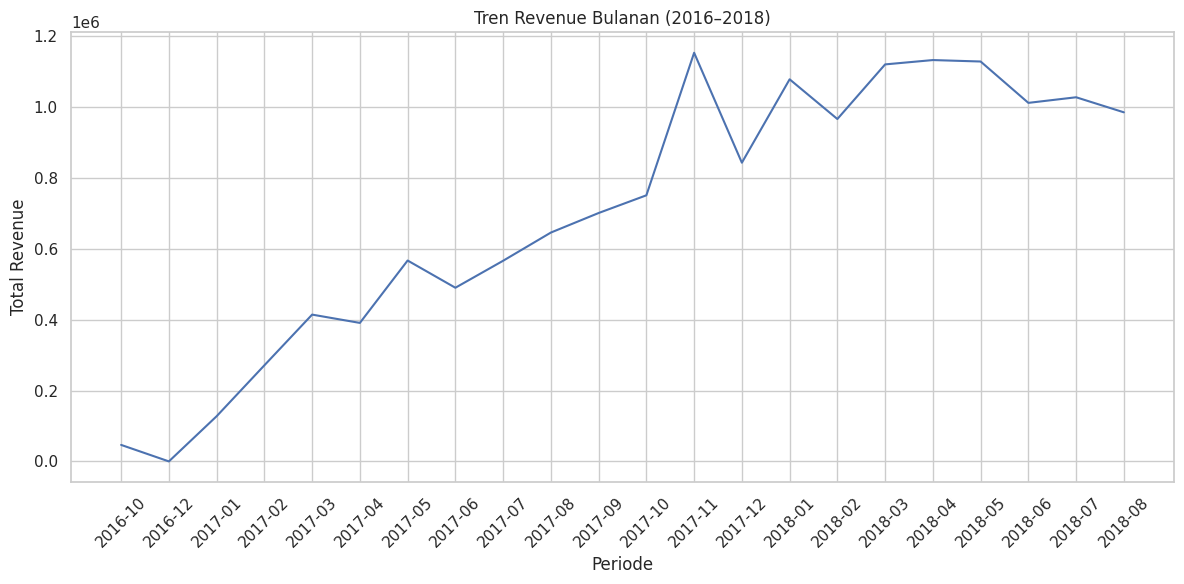

In [42]:
plt.figure(figsize=(12,6))
plt.plot(monthly_revenue["year_month"],
         monthly_revenue["payment_value"])

plt.xticks(rotation=45)
plt.title("Tren Revenue Bulanan (2016–2018)")
plt.xlabel("Periode")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

Pada akhir 2016, revenue masih relatif rendah. Memasuki tahun 2017, terlihat peningkatan yang cukup konsisten dari bulan ke bulan. Ini menunjukkan bahwa:


*   Platform sedang dalam fase ekspansi
*   Kemungkinan peningkatan jumlah pengguna aktif
*   Akuisisi pelanggan mulai efektif

Kenaikan bertahap ini mengindikasikan pertumbuhan organik yang sehat





### Pertanyaan 2: Bagaimana distribusi frekuensi pembelian pelanggan dan persentase repeat buyer?

In [43]:
customer_orders = pd.merge(
    orders_df,
    customers_df,
    on="customer_id",
    how="inner"
)

freq_df = (
    customer_orders
    .groupby("customer_unique_id")["order_id"]
    .count()
    .reset_index()
)

freq_df.rename(columns={"order_id": "total_orders"}, inplace=True)

freq_df["customer_type"] = freq_df["total_orders"].apply(
    lambda x: "Repeat Buyer" if x > 1 else "One-time Buyer"
)

In [44]:
customer_type_counts = freq_df["customer_type"].value_counts()

repeat_customers = freq_df[freq_df["total_orders"] > 1].shape[0]
total_customers = freq_df.shape[0]

percentage_repeat = (repeat_customers / total_customers) * 100

print("Total Customers:", total_customers)
print("Repeat Buyers:", repeat_customers)
print("Persentase Repeat Buyer: {:.2f}%".format(percentage_repeat))

Total Customers: 93358
Repeat Buyers: 2801
Persentase Repeat Buyer: 3.00%


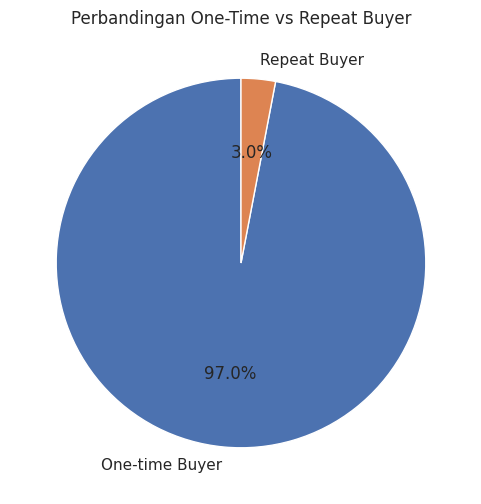

In [45]:
plt.figure(figsize=(6,6))

plt.pie(
    customer_type_counts.values,
    labels=customer_type_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Perbandingan One-Time vs Repeat Buyer")

plt.show()

**Insight:**
- Dari total 93.358 pelanggan, hanya 2.801 pelanggan (3%) yang melakukan pembelian lebih dari satu kali. Sebaliknya, sekitar 97% pelanggan merupakan one-time buyer.
- Distribusi frekuensi pembelian menunjukkan bahwa mayoritas pelanggan hanya melakukan satu transaksi selama periode 2016–2018
- Hal ini mengindikasikan tingkat retensi pelanggan yang sangat rendah dan menunjukkan bahwa bisnis masih sangat bergantung pada akuisisi pelanggan baru dibandingkan mempertahankan pelanggan lama

# Conclusion

## Conclusion Pertanyaan 1

Berdasarkan hasil agregasi revenue bulanan, terlihat bahwa platform e-commerce mengalami pertumbuhan yang signifikan dari tahun 2016 hingga 2018. Volume transaksi dan total revenue menunjukkan tren meningkat secara konsisten, terutama memasuki tahun 2017 dan mencapai puncaknya pada tahun 2018.

Meskipun terdapat fluktuasi antarbulan, pola umum menunjukkan ekspansi bisnis yang stabil. Distribusi nilai transaksi yang cenderung right-skewed juga mengindikasikan bahwa pertumbuhan revenue lebih banyak didorong oleh banyaknya transaksi bernilai kecil dibandingkan oleh transaksi bernilai besar.

Hal ini menunjukkan bahwa model bisnis platform cenderung mengandalkan volume transaksi yang tinggi sebagai pendorong utama pertumbuhan revenue.

## Conclusion Pertanyaan 2

Hasil analisis menunjukkan bahwa dari total 93.358 pelanggan, hanya sekitar 3% yang melakukan pembelian lebih dari satu kali, sementara sekitar 97% pelanggan hanya melakukan satu transaksi selama periode 2016–2018.

Distribusi frekuensi pembelian memperlihatkan bahwa sebagian besar pelanggan merupakan one-time buyer. Hal ini mengindikasikan tingkat retensi pelanggan yang rendah, sehingga pertumbuhan bisnis kemungkinan besar lebih bergantung pada akuisisi pelanggan baru dibandingkan loyalitas pelanggan lama.

Rendahnya persentase repeat buyer membuka peluang strategis bagi perusahaan untuk meningkatkan retensi melalui program loyalitas, promosi khusus pelanggan lama, atau strategi customer relationship management (CRM) yang lebih optimal.